# Análisis Exploratorio Para El Problema de Regresión (House Pricing)

In [53]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import itertools 
from scipy import stats
from pathlib import Path 


In [2]:
ds_path = Path("../ml-project/data/raw/dataset_regresion.csv")
data = pd.read_csv(ds_path, sep=",")

pd.set_option("display.max_columns", None)

In [ ]:

var_num = data.select_dtypes(include= [np.int64, np.float64]).columns.tolist()
var_cat = data.select_dtypes(include=['string']).columns.tolist()



['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value']

## Diccionario de variables

| Nombre de la variable    | Descripción                                                                                              | Tipo de variable   |
| :----------------------- | :------------------------------------------------------------------------------------------------------- | :----------------- |
| **`longitude`**          | Coordenada de longitud. Indica qué tan al oeste se encuentra el distrito.                                | Numérica continua  |
| **`latitude`**           | Coordenada de latitud. Indica qué tan al norte se encuentra el distrito.                                 | Numérica continua  |
| **`housing_median_age`** | Edad mediana de las viviendas dentro del bloque.                                                         | Numérica continua  |
| **`total_rooms`**        | Número total de habitaciones presentes en el distrito o bloque.                                          | Numérica discreta  |
| **`total_bedrooms`**     | Número total de dormitorios en el distrito o bloque. *(Contiene valores nulos)*.                         | Numérica discreta  |
| **`population`**         | Número total de personas (población) que residen en ese bloque.                                          | Numérica discreta  |
| **`households`**         | Número total de hogares (personas que conviven en una misma unidad) en el bloque.                        | Numérica discreta  |
| **`median_income`**      | Ingreso mediano de los hogares en el bloque (escalado en decenas de miles de dólares).                   | Numérica continua  |
| **`median_house_value`** | Valor mediano de las viviendas en el bloque (en dólares). **[Variable Objetivo]**                        | Numérica continua  |
| **`ocean_proximity`**    | Ubicación de la vivienda respecto al océano (`<1H OCEAN`, `INLAND`, `NEAR OCEAN`, `NEAR BAY`, `ISLAND`). | Categórica nominal |

## Histograma de las variables

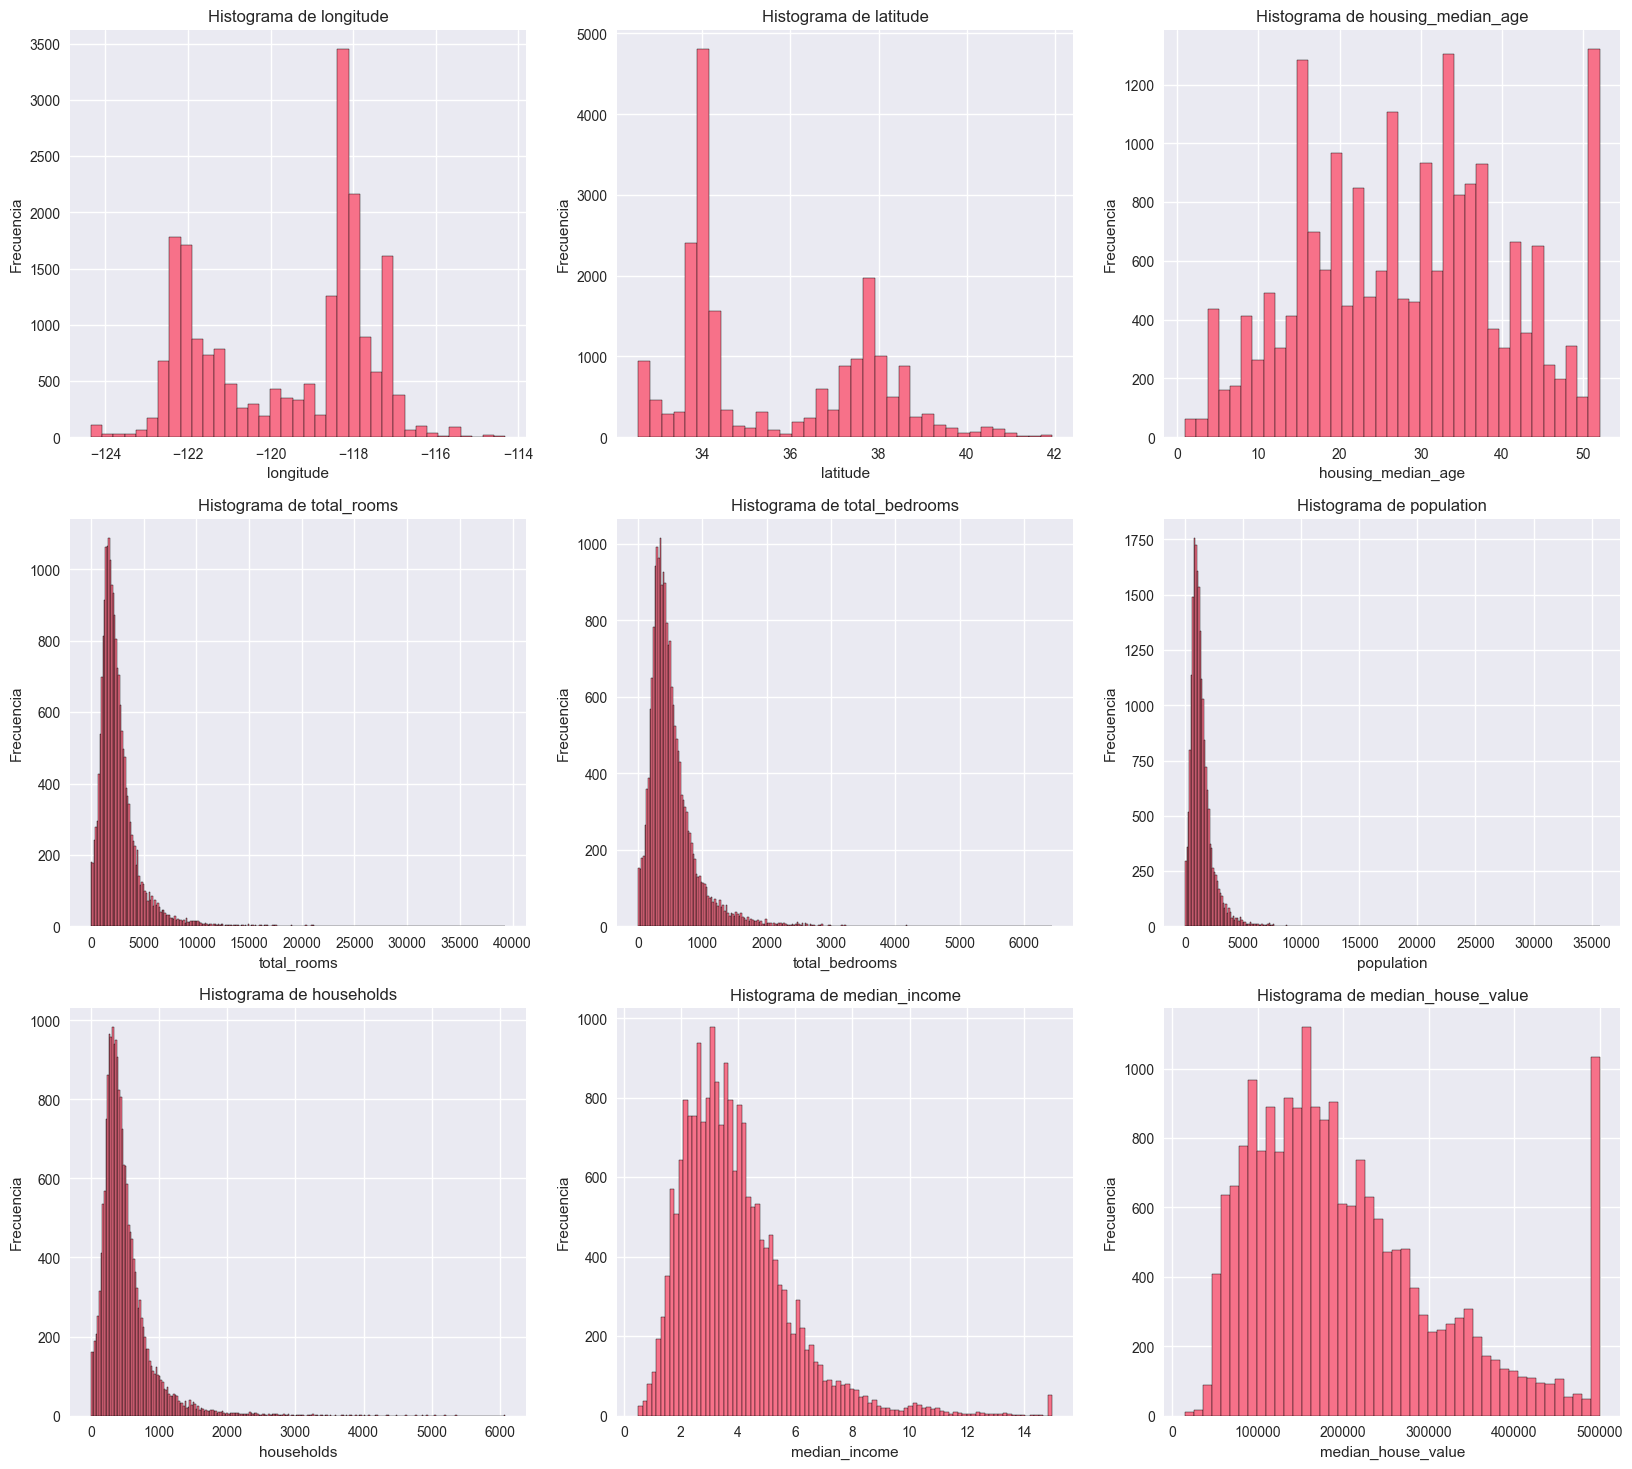

In [24]:
fig, axes = plt.subplots(3,3, figsize=(20,18))
axes = axes.ravel()
for i, var in enumerate(var_num):
    axes[i].hist(data[var], bins='auto', alpha=1, edgecolor='black')
    axes[i].set_title(f"Histograma de {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Frecuencia")


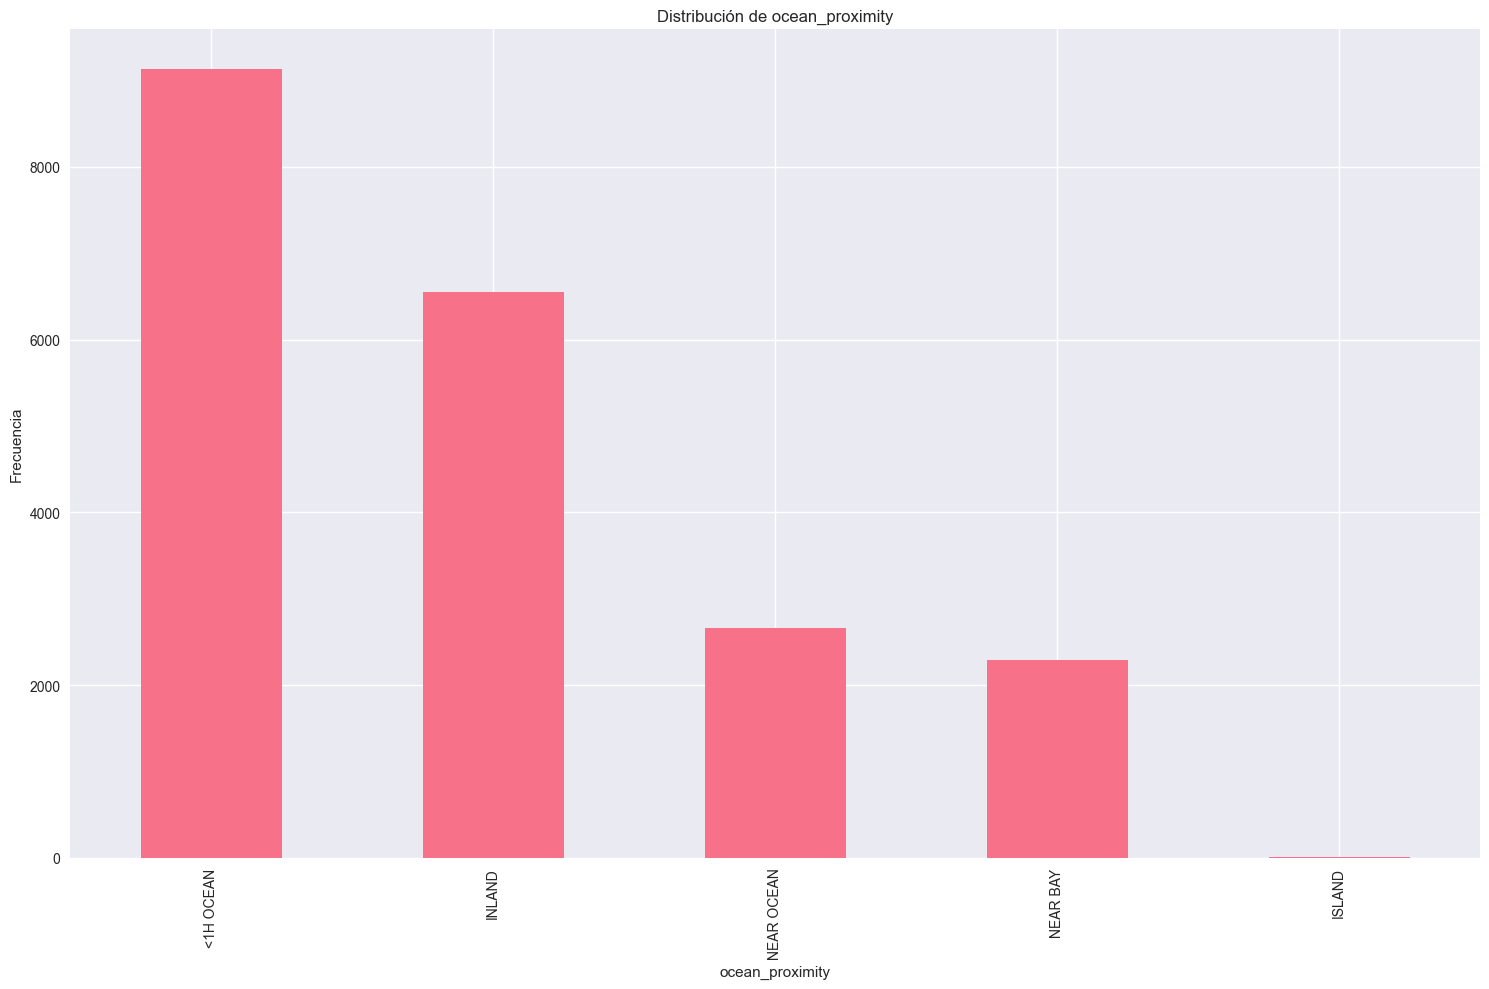

In [34]:
fig, axes = plt.subplots(1, len(var_cat), figsize=(15,10))

if len(var_cat) == 1:
    axes = [axes]

for i, var in enumerate(var_cat):
    data[var].value_counts().plot(
        kind='bar',
        ax=axes[i]
    )
    axes[i].set_title(f"Distribución de {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

In [37]:
data[var_num].agg(['mean', 'median', 'std'])


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
median,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874


In [38]:
data[var_cat].agg(['mode'])

,ocean_proximity
,mode
0,<1H OCEAN


## Correlación entre variables


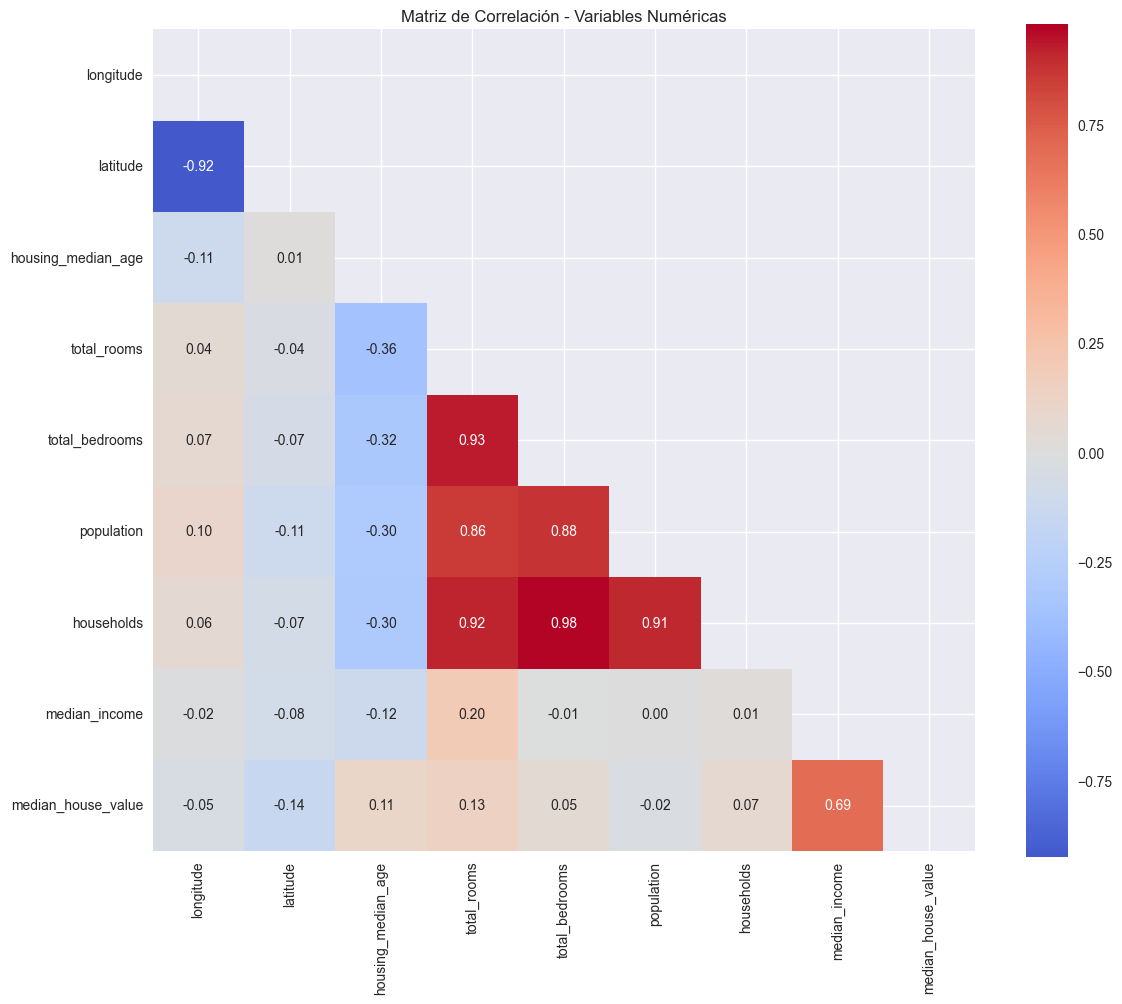

In [ ]:
plt.figure(figsize=(12, 10))
corr = data.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()

## Datos Atípicos

In [40]:
import numpy as np

outliers = {}

for col in var_num:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers[col] = data[(data[col] < lower) | (data[col] > upper)]

    print(f"{col}: {len(outliers[col])} outliers")

longitude: 0 outliers
latitude: 0 outliers
housing_median_age: 0 outliers
total_rooms: 1287 outliers
total_bedrooms: 1271 outliers
population: 1196 outliers
households: 1220 outliers
median_income: 681 outliers
median_house_value: 1071 outliers


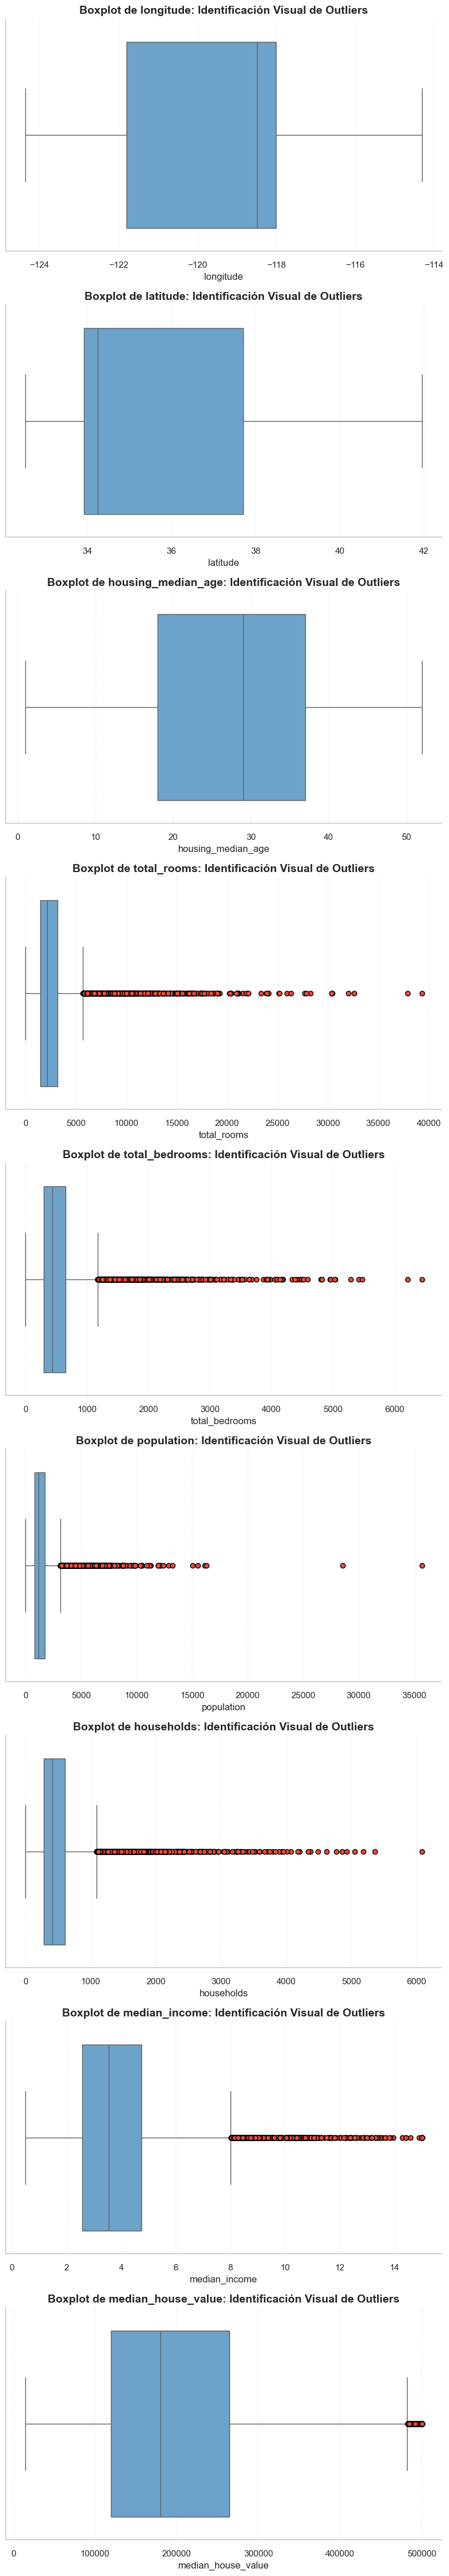

In [ ]:
columnas = 1  
filas = len(var_num)


fig, axes = plt.subplots(filas, columnas, figsize=(8, filas * 5))


if filas == 1:
    axes = [axes]

sns.set_theme(style="whitegrid")

for i, var in enumerate(var_num):
  

    sns.boxplot(data=data, x=var, ax=axes[i], color="#5da5da", 
                flierprops={"marker": "o", "markersize": 6, "markerfacecolor": "#e74c3c", "markeredgecolor": "black"})
    

    axes[i].set_title(f"Boxplot de {var}: Identificación Visual de Outliers", fontsize=14, weight='bold')
    axes[i].set_xlabel(var, fontsize=12)
    
    axes[i].grid(axis='x', alpha=0.3, linestyle='--')


sns.despine()
plt.tight_layout()
plt.show()

Pares encontrados con |corr| >= 0.3: 11


,var_x,var_y,corr
0,total_bedrooms,households,0.980
1,total_rooms,total_bedrooms,0.930
2,longitude,latitude,-0.925
3,total_rooms,households,0.918
4,population,households,0.907
5,total_bedrooms,population,0.878
6,total_rooms,population,0.857
7,median_income,median_house_value,0.688
8,housing_median_age,total_rooms,-0.361
9,housing_median_age,total_bedrooms,-0.320


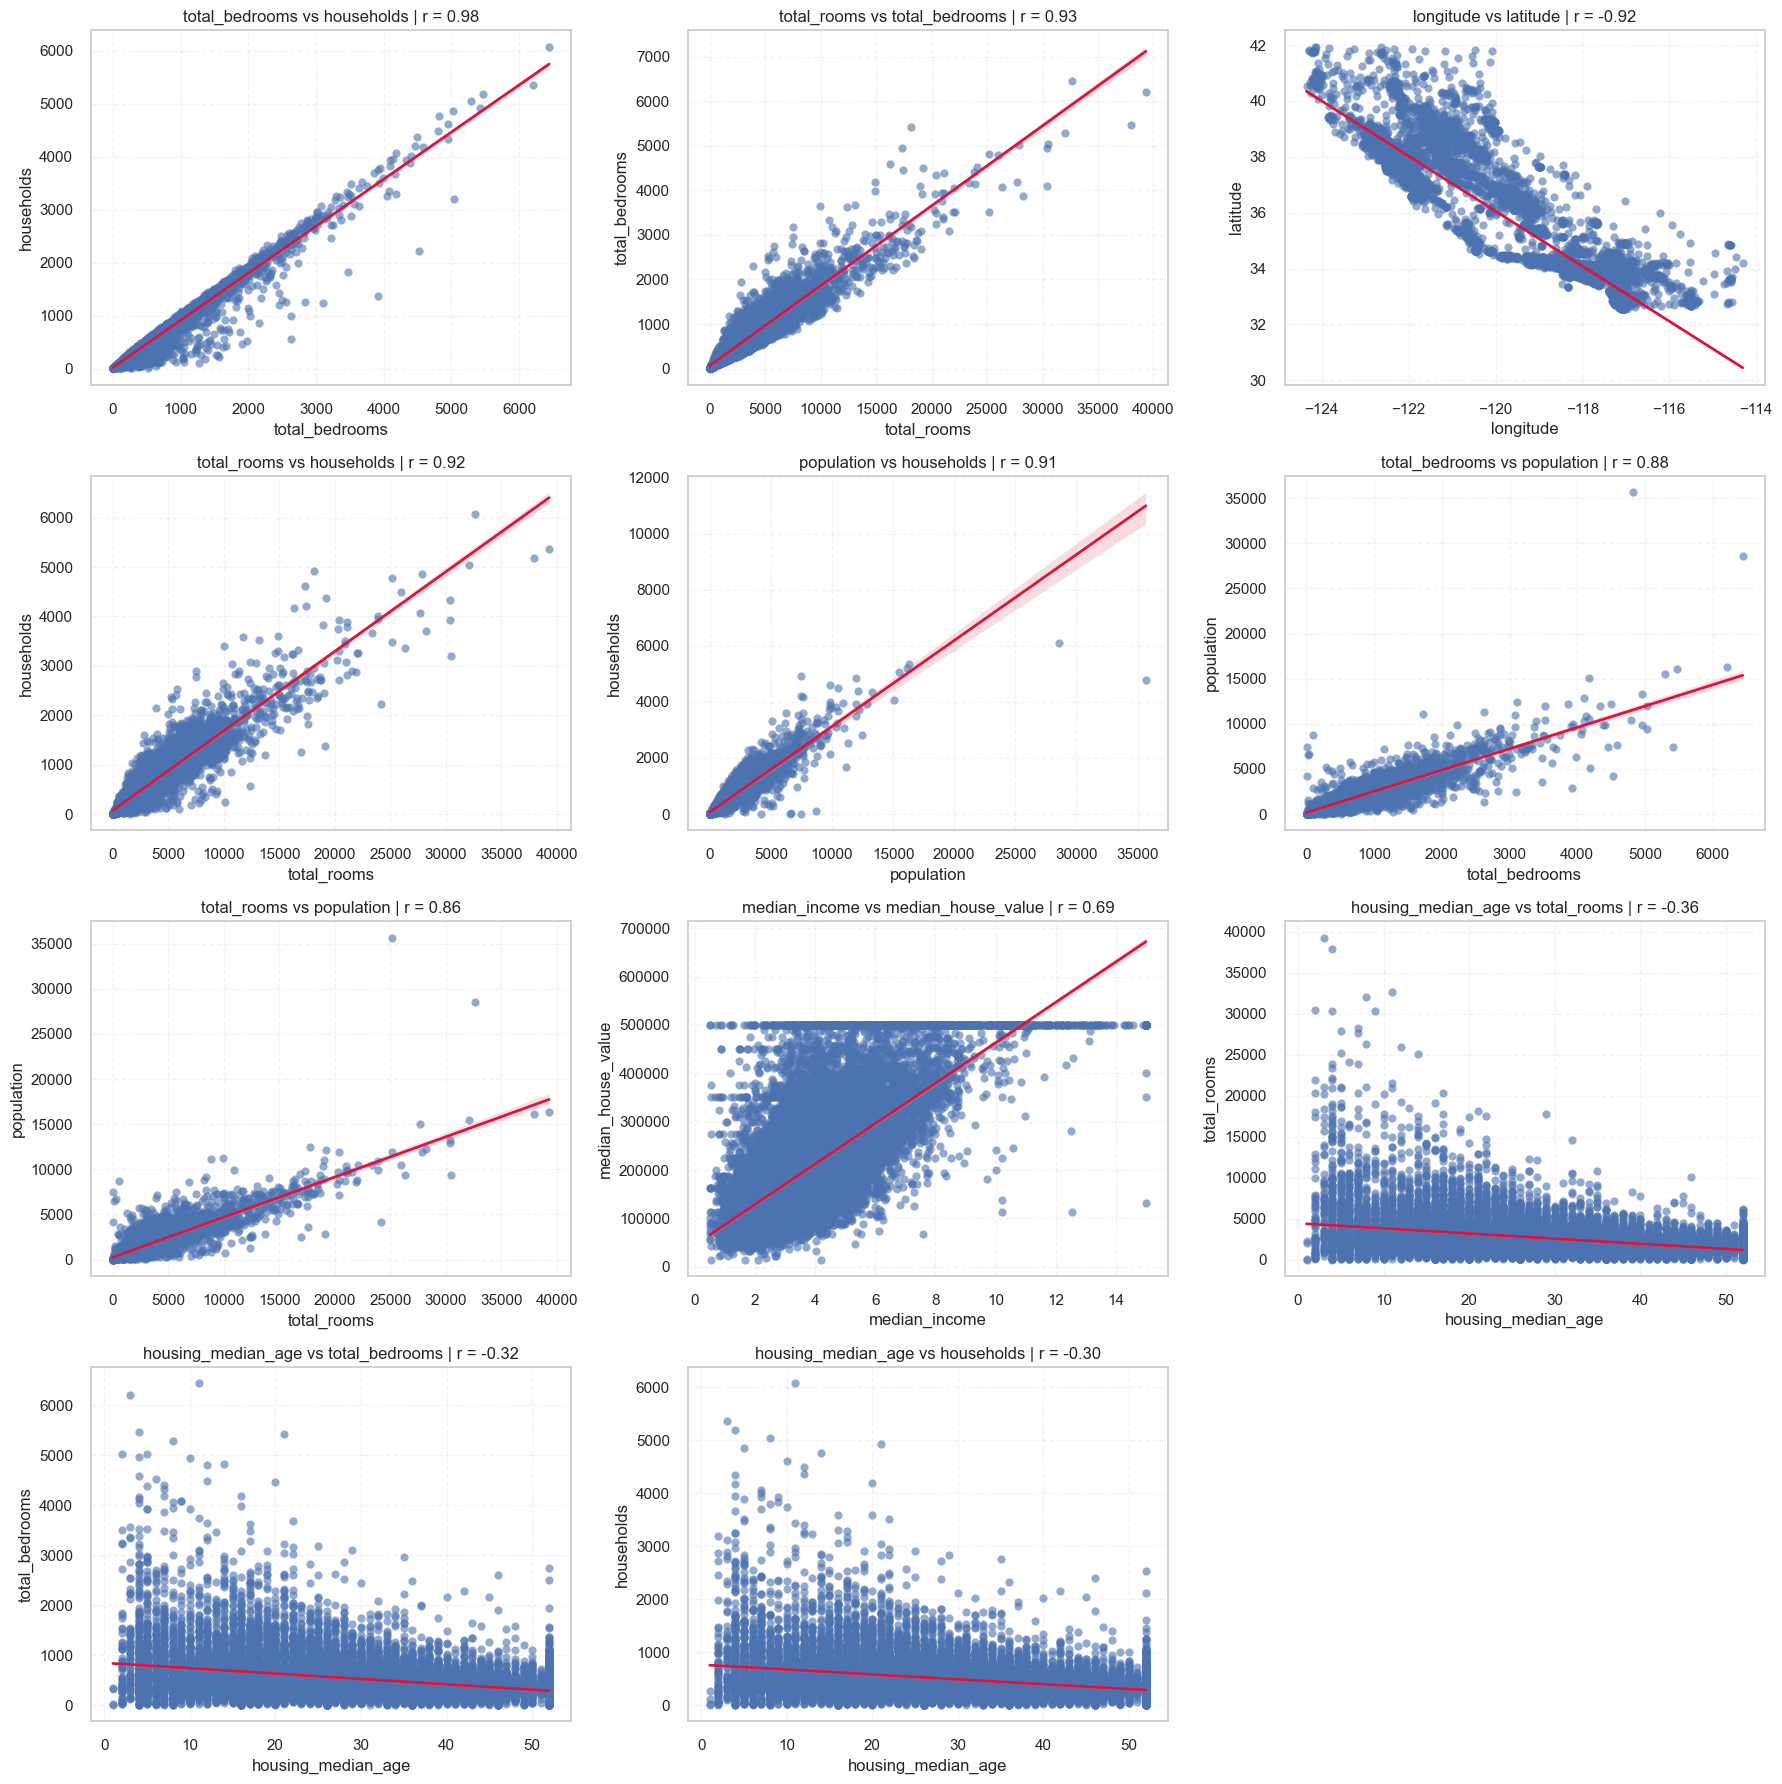

In [55]:
umbral_corr = 0.30
metodo_corr = "pearson"   # también puedes usar: "spearman"

df_num = data[var_num].copy()
corr = df_num.corr(method=metodo_corr)

# Buscar pares de variables con correlación (en valor absoluto) >= umbral
pares_corr = []
for x, y in itertools.combinations(corr.columns, 2):
    r = corr.loc[x, y]
    if pd.notna(r) and np.isfinite(r) and abs(r) >= umbral_corr:
        pares_corr.append((x, y, r))

pares_corr = sorted(pares_corr, key=lambda t: abs(t[2]), reverse=True)

print(f"Pares encontrados con |corr| >= {umbral_corr}: {len(pares_corr)}")
display(pd.DataFrame(pares_corr, columns=["var_x", "var_y", "corr"]).round(3))

if len(pares_corr) == 0:
    print("No hay pares con ese umbral. Prueba bajar umbral_corr.")
else:
    n = len(pares_corr)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4.5*nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (x, y, r) in zip(axes, pares_corr):
        sns.regplot(
            data=df_num, x=x, y=y, ax=ax,
            scatter_kws={"alpha": 0.6, "s": 35},
            line_kws={"color": "crimson", "lw": 2}
        )
        ax.set_title(f"{x} vs {y} | r = {r:.2f}")
        ax.grid(alpha=0.25, linestyle="--")

    # Ocultar ejes sobrantes
    for ax in axes[n:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()